<a href="https://colab.research.google.com/github/kowsik005/ml_supervised_project/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Salary prediction

Dataset loaded successfully!

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Dataset shape:
(397, 33)

Column names:
['s

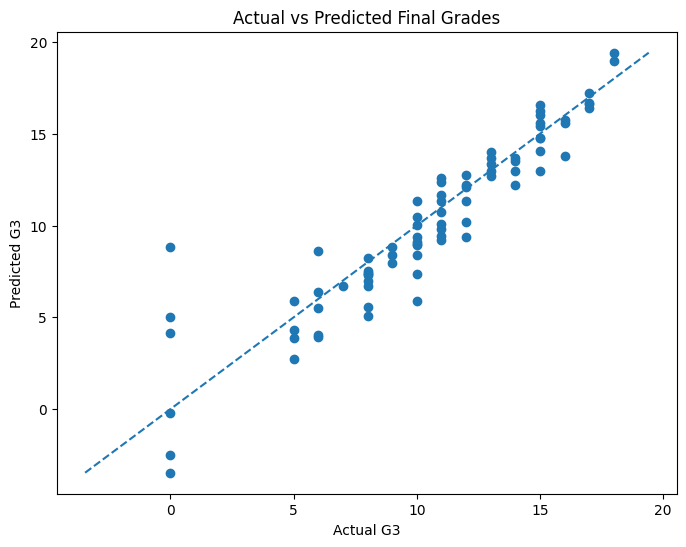

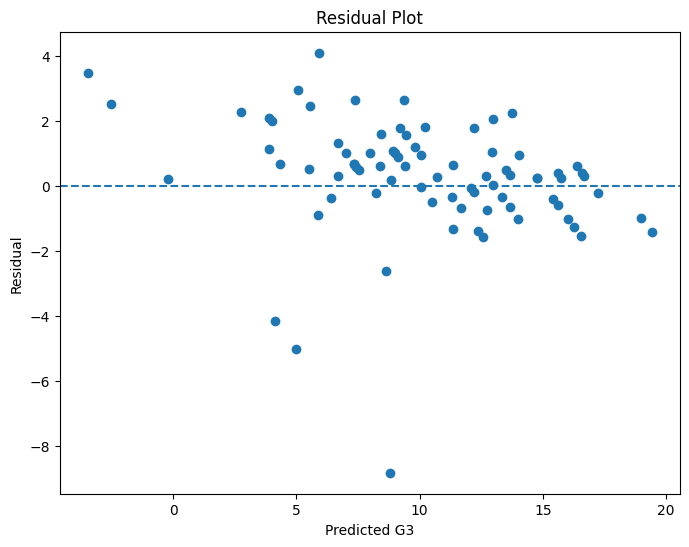


NEW STUDENT PREDICTION
Predicted Final Grade (G3): 11.79


In [26]:
# ============================================================
# LINEAR REGRESSION - MATHS DATASET
# ============================================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 2. LOAD DATASET
# ============================================================

# IMPORTANT:
# Maths.csv is actually an Excel file, so use read_excel()
df = pd.read_excel("Maths.csv", sheet_name="Maths")

print("Dataset loaded successfully!")

# ============================================================
# 3. DISPLAY DATASET INFORMATION
# ============================================================

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

# ============================================================
# 4. DEFINE INPUT AND OUTPUT
# ============================================================

# Target variable
# G3 = Final grade
y = df["G3"]

# Remove target from input variables
X = df.drop("G3", axis=1)

print("\nInput features:")
print(X.columns.tolist())

print("\nTarget variable: G3")

# ============================================================
# 5. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

# ============================================================
# 6. PREPROCESS CATEGORICAL DATA
# ============================================================

# Convert categorical columns into numerical values
# using One-Hot Encoding

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numerical",
            "passthrough",
            numeric_columns
        )
    ]
)

# ============================================================
# 7. CREATE LINEAR REGRESSION MODEL
# ============================================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# ============================================================
# 8. SPLIT DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data size:", X_train.shape)
print("Testing data size:", X_test.shape)

# ============================================================
# 9. TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully!")

# ============================================================
# 10. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\nPredicted values:")
print(y_pred[:10])

print("\nActual values:")
print(y_test.values[:10])

# ============================================================
# 11. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n===================================")
print("LINEAR REGRESSION RESULTS")
print("===================================")

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R2 Score:", r2)

# ============================================================
# 12. ACTUAL VS PREDICTED VALUES
# ============================================================

results = pd.DataFrame({
    "Actual G3": y_test.values,
    "Predicted G3": y_pred
})

print("\nActual vs Predicted:")
print(results.head(20))

# ============================================================
# 13. PLOT ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")

plt.title("Actual vs Predicted Final Grades")

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()

# ============================================================
# 14. PLOT RESIDUALS
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted G3")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# ============================================================
# 15. PREDICT A NEW STUDENT
# ============================================================

# Example student
# All required columns are taken from the dataset.

new_student = pd.DataFrame({
    "school": ["GP"],
    "sex": ["F"],
    "age": [16],
    "address": ["U"],
    "famsize": ["GT3"],
    "Pstatus": ["T"],
    "Medu": [3],
    "Fedu": [3],
    "Mjob": ["teacher"],
    "Fjob": ["other"],
    "reason": ["course"],
    "guardian": ["mother"],
    "traveltime": [1],
    "studytime": [2],
    "failures": [0],
    "schoolsup": ["yes"],
    "famsup": ["yes"],
    "paid": ["no"],
    "activities": ["no"],
    "nursery": ["yes"],
    "higher": ["yes"],
    "internet": ["yes"],
    "romantic": ["no"],
    "famrel": [4],
    "freetime": [3],
    "goout": [3],
    "Dalc": [1],
    "Walc": [2],
    "health": [3],
    "absences": [4],
    "G1": [10],
    "G2": [11]
})

# Predict final grade
new_prediction = model.predict(new_student)

print("\n===================================")
print("NEW STUDENT PREDICTION")
print("===================================")

print("Predicted Final Grade (G3):",
      round(new_prediction[0], 2))

# ============================================================
# END
# ============================================================